# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# StandardScaler  : scales features to zero mean and unit variance (z-score)
# PCA             : Principal Component Analysis — dimensionality reduction
# KMeans          : K-Means clustering algorithm
# silhouette_score     : measures how well-separated clusters are (higher = better)
# davies_bouldin_score : measures average similarity between clusters (lower = better)

# Task 1 — Exploratory Data Analysis (EDA)

In [2]:
# DATA LOADING
df = pd.read_csv("wine.csv")
print("Dataset loaded successfully.")
print(f"Shape : {df.shape}  ({df.shape[0]} wine samples, {df.shape[1]} columns)")

Dataset loaded successfully.
Shape : (178, 14)  (178 wine samples, 14 columns)


In [3]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
df.isna().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


# VISUALISATION 1 — Wine Type Distribution

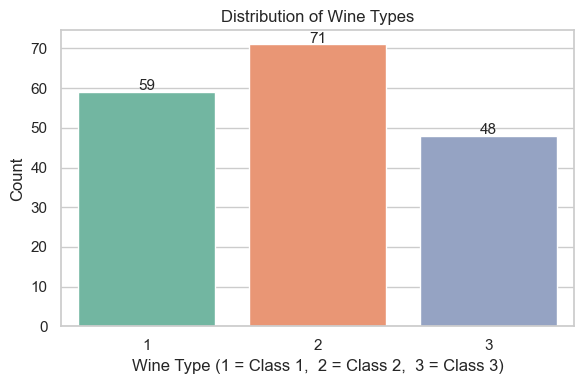

In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Type", data=df, palette="Set2")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                ha="center", fontsize=11)
plt.title("Distribution of Wine Types")
plt.xlabel("Wine Type (1 = Class 1,  2 = Class 2,  3 = Class 3)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# VISUALISATION 2 — Histograms with KDE for all features

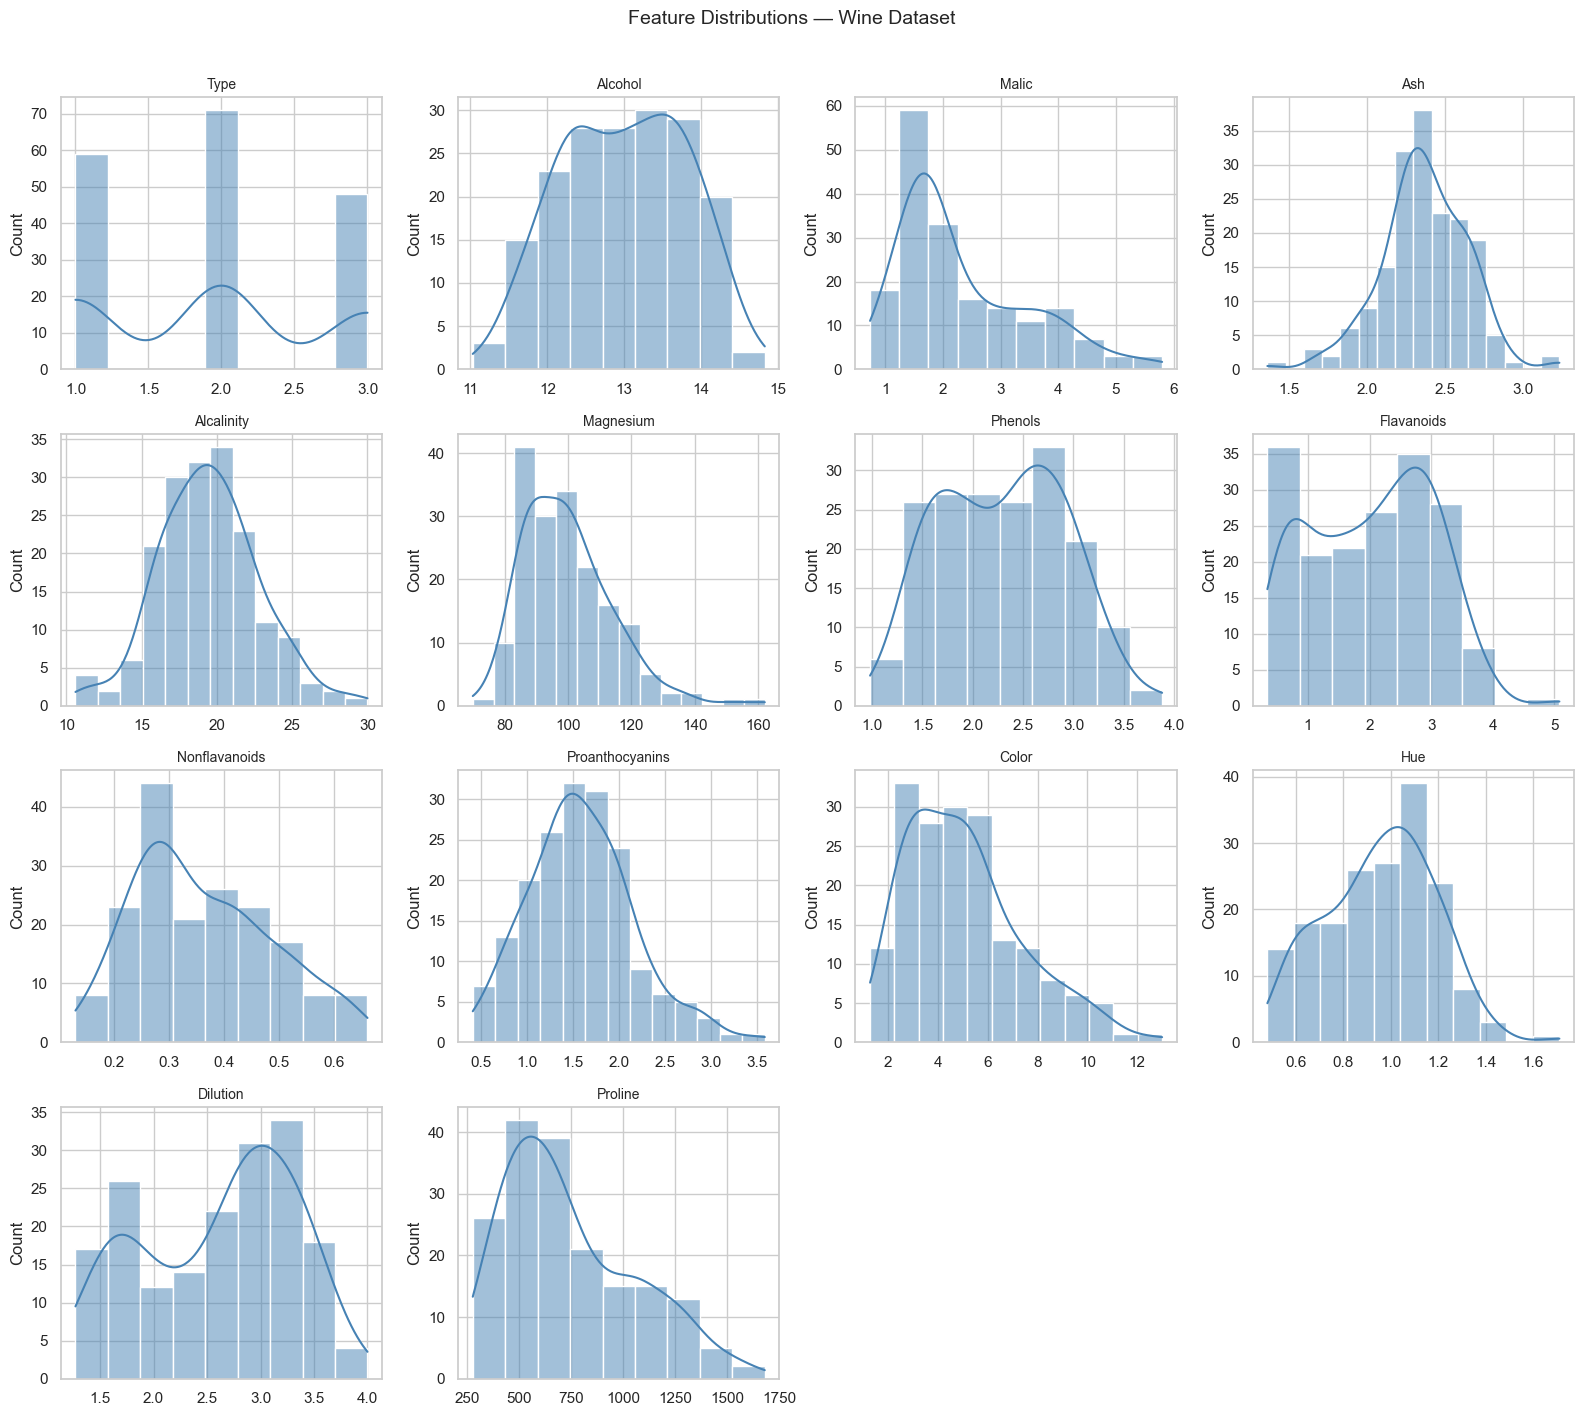

In [9]:
feature_cols = df.columns.tolist()   # includes all 14 columns

plt.figure(figsize=(16, 14))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True, color="steelblue")
    plt.title(col, fontsize=10)
    plt.xlabel("")
plt.suptitle("Feature Distributions — Wine Dataset", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# VISUALISATION 3 — Boxplots for Outlier Detection

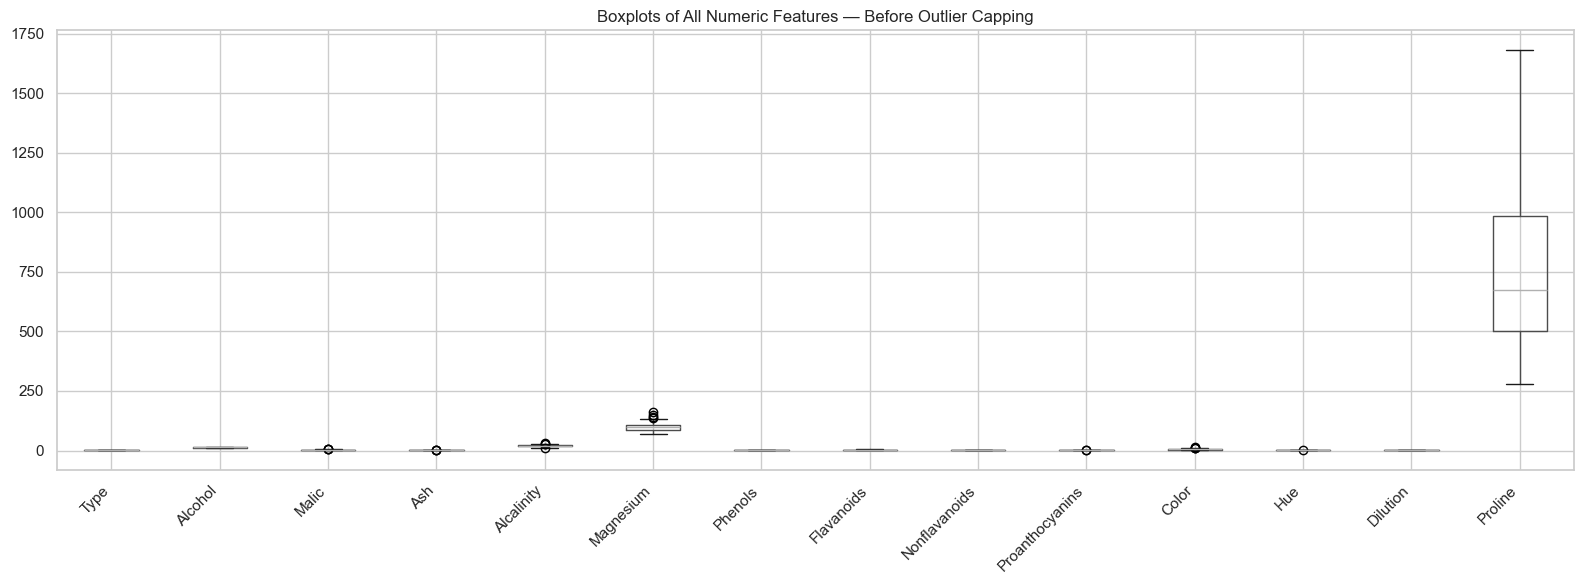

In [10]:
plt.figure(figsize=(16, 6))
df.select_dtypes(include=["float64", "int64"]).boxplot()
plt.title("Boxplots of All Numeric Features — Before Outlier Capping")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# OUTLIER CAPPING (IQR Method)
def outlier_capping(df, column):
    """Caps outliers in a numeric column using the IQR fence method (in-place)."""
    Q1  = df[column].quantile(0.25)
    Q3  = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    df[column] = df[column].apply(
        lambda x: lower_fence if x < lower_fence
                  else upper_fence if x > upper_fence
                  else x)
# Apply to all numeric feature columns except the class label 'Type'
feature_only_cols = [c for c in df.select_dtypes(["int", "float"]).columns if c != "Type"]
for col in feature_only_cols:
    outlier_capping(df, col)

print("Outlier capping applied to all feature columns.")


Outlier capping applied to all feature columns.


# VISUALISATION 4 — Boxplots AFTER Outlier Capping

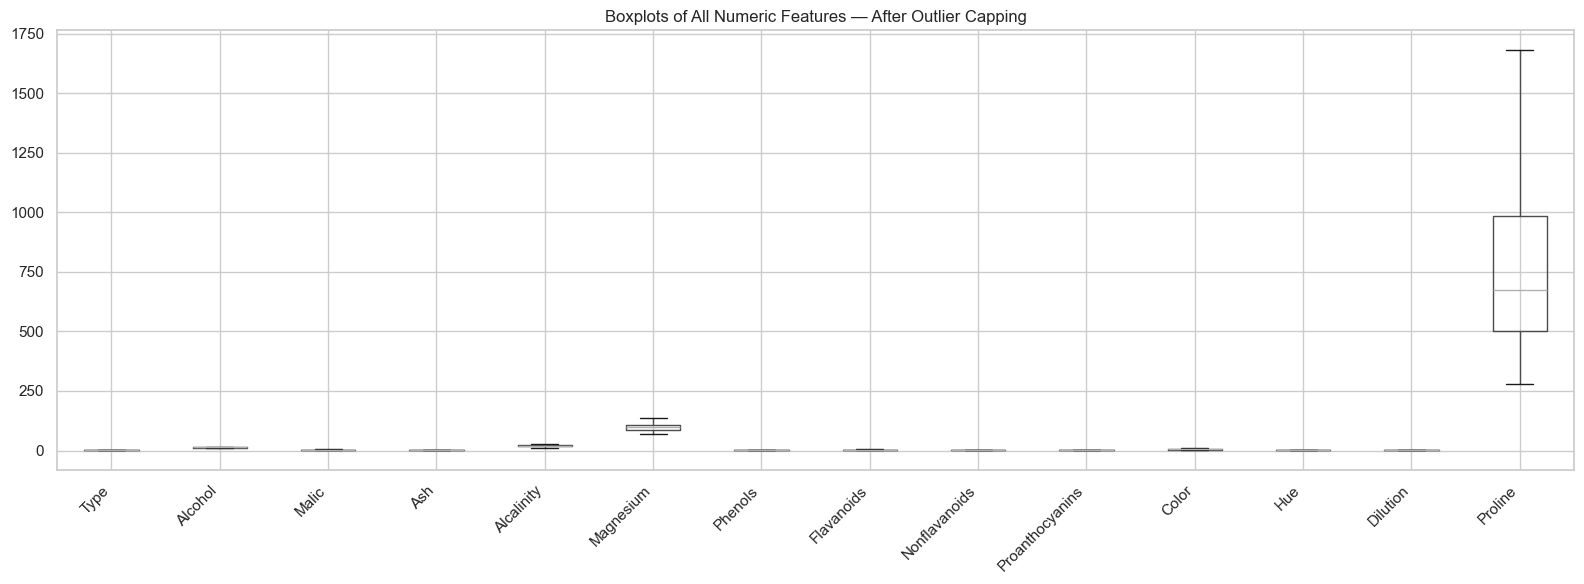

In [12]:
plt.figure(figsize=(16, 6))
df.select_dtypes(include=["float64", "int64"]).boxplot()
plt.title("Boxplots of All Numeric Features — After Outlier Capping")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# VISUALISATION 5 — Correlation Heatmap

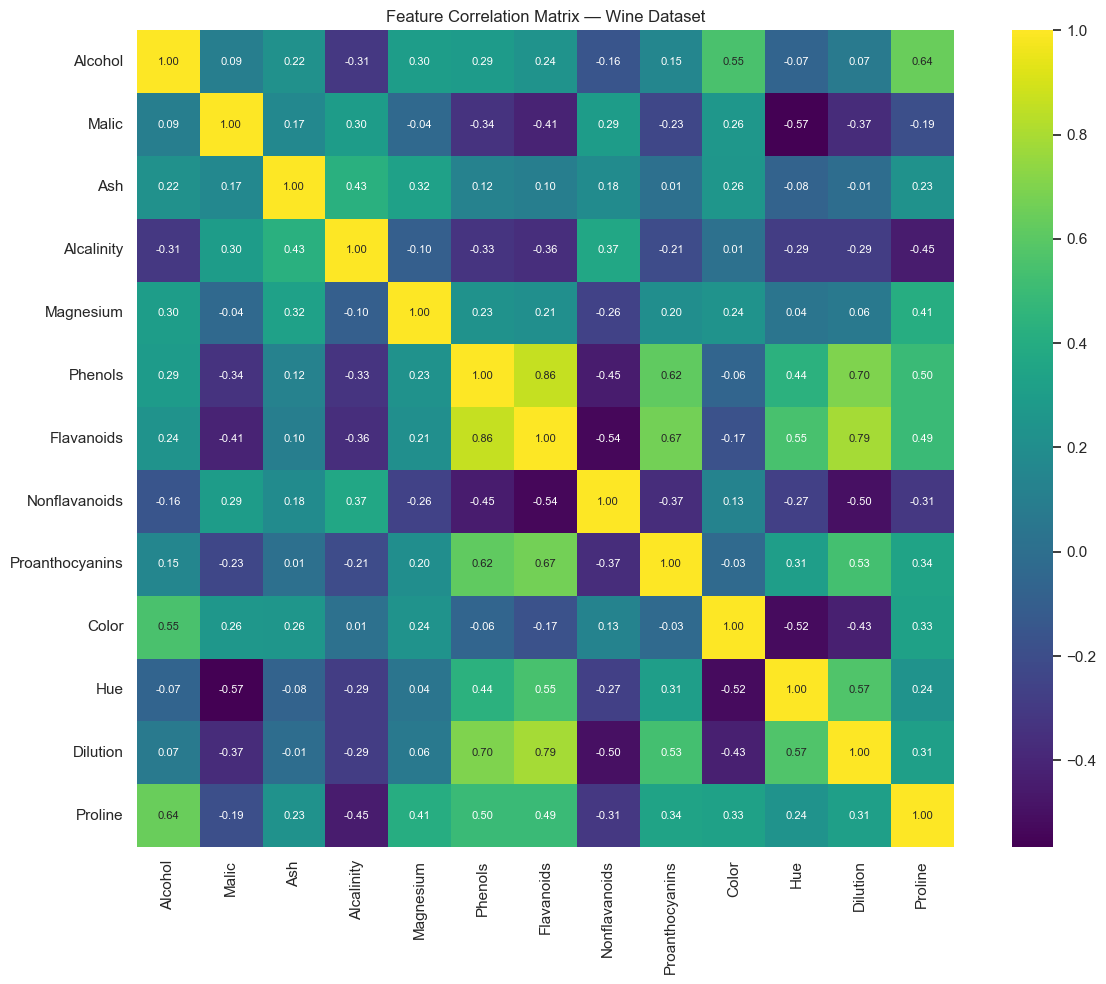

In [13]:
corr = df.drop(columns=["Type"]).corr()   # exclude class label from correlation

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f", square=True,
            annot_kws={"size": 8})
plt.title("Feature Correlation Matrix — Wine Dataset")
plt.tight_layout()
plt.show()

# Task 2 — Dimensionality Reduction with PCA

In [14]:
feature_cols = [c for c in df.columns if c != "Type"]

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(df[feature_cols])

print("Standardisation complete.")
print(f"Scaled data shape: {x_scaled.shape}  ({x_scaled.shape[0]} samples × {x_scaled.shape[1]} features)")
print(f"Feature means (should be ~0): {x_scaled.mean(axis=0).round(3)}")
# excluded the 'Type' column (class label) from scaling — it is not an input feature; it will be used only for colour-coding visualisations

Standardisation complete.
Scaled data shape: (178, 13)  (178 samples × 13 features)
Feature means (should be ~0): [-0.  0. -0. -0. -0.  0. -0.  0.  0. -0. -0.  0. -0.]


In [15]:
# STEP 2 — Apply Full PCA (all components)
pca_full = PCA()
pca_full.fit(x_scaled)

explained     = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print("Variance explained by each Principal Component:")
for i, (e, c) in enumerate(zip(explained, cum_explained), 1):
    print(f"  PC{i:2d} : {e:.4f}  ({e*100:.1f}%)   cumulative: {c*100:.1f}%")


Variance explained by each Principal Component:
  PC 1 : 0.3648  (36.5%)   cumulative: 36.5%
  PC 2 : 0.1961  (19.6%)   cumulative: 56.1%
  PC 3 : 0.1091  (10.9%)   cumulative: 67.0%
  PC 4 : 0.0706  (7.1%)   cumulative: 74.1%
  PC 5 : 0.0630  (6.3%)   cumulative: 80.4%
  PC 6 : 0.0482  (4.8%)   cumulative: 85.2%
  PC 7 : 0.0403  (4.0%)   cumulative: 89.2%
  PC 8 : 0.0274  (2.7%)   cumulative: 91.9%
  PC 9 : 0.0223  (2.2%)   cumulative: 94.2%
  PC10 : 0.0193  (1.9%)   cumulative: 96.1%
  PC11 : 0.0176  (1.8%)   cumulative: 97.9%
  PC12 : 0.0133  (1.3%)   cumulative: 99.2%
  PC13 : 0.0081  (0.8%)   cumulative: 100.0%


# VISUALISATION 6 — Scree Plot

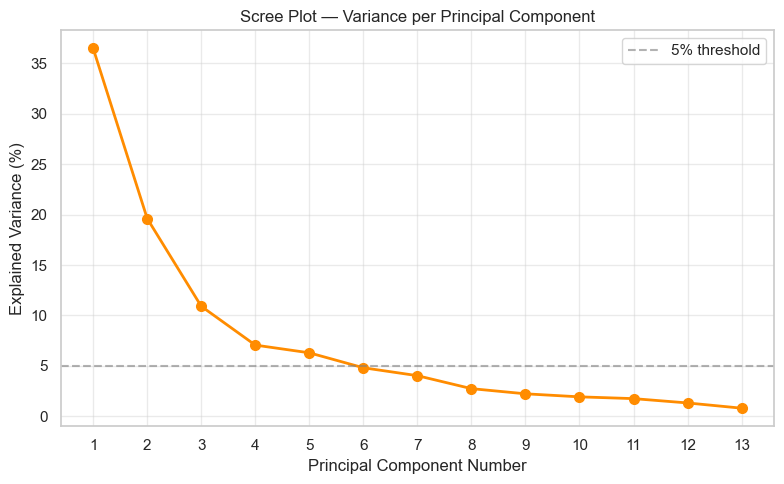

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained) + 1), explained * 100, marker="o",
         color="darkorange", linewidth=2, markersize=7)
plt.axhline(y=5, color="gray", linestyle="--", alpha=0.6, label="5% threshold")
plt.xlabel("Principal Component Number")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot — Variance per Principal Component")
plt.xticks(range(1, len(explained) + 1))
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# VISUALISATION 7 — Cumulative Explained Variance Plot

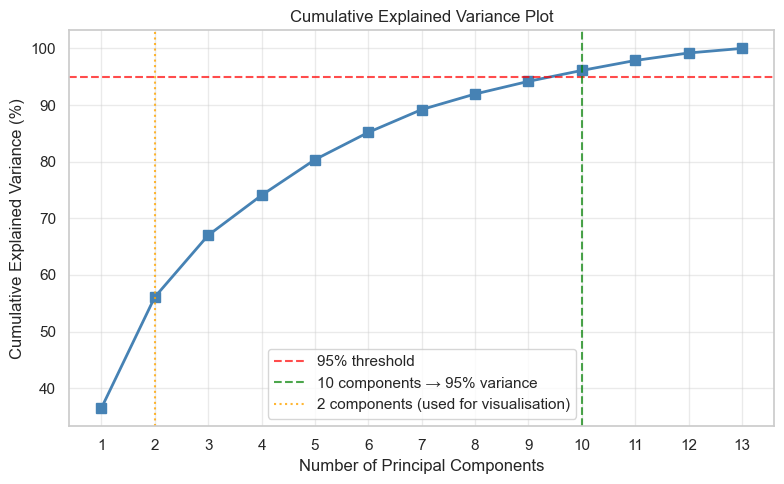

Components needed to explain 95% of variance: 10
Variance explained by first 2 components: 56.1%


In [17]:
n_95 = np.argmax(cum_explained >= 0.95) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_explained) + 1), cum_explained * 100,
         marker="s", color="steelblue", linewidth=2, markersize=7)
plt.axhline(y=95, color="red", linestyle="--", alpha=0.7, label="95% threshold")
plt.axvline(x=n_95, color="green", linestyle="--", alpha=0.7,
            label=f"{n_95} components → 95% variance")
plt.axvline(x=2, color="orange", linestyle=":", alpha=0.8,
            label="2 components (used for visualisation)")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance Plot")
plt.xticks(range(1, len(cum_explained) + 1))
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Components needed to explain 95% of variance: {n_95}")
print(f"Variance explained by first 2 components: {cum_explained[1]*100:.1f}%")


In [18]:
# STEP 3 — Transform Dataset to 2 Principal Components
pca2       = PCA(n_components=2)
x_pca2     = pca2.fit_transform(x_scaled)

print(f"Original data shape  : {x_scaled.shape}")
print(f"PCA-reduced shape    : {x_pca2.shape}")
print(f"Variance retained    : {pca2.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1 explains       : {pca2.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2 explains       : {pca2.explained_variance_ratio_[1]*100:.1f}%")

Original data shape  : (178, 13)
PCA-reduced shape    : (178, 2)
Variance retained    : 56.1%
  PC1 explains       : 36.5%
  PC2 explains       : 19.6%


# VISUALISATION 8 — PCA Scatter Plot (coloured by true Wine Type)

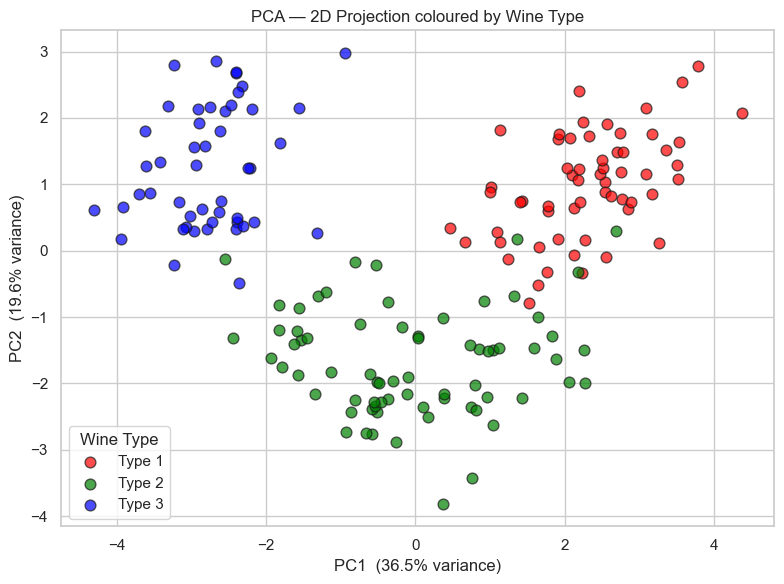

In [19]:
plt.figure(figsize=(8, 6))
colors = {1: "red", 2: "green", 3: "blue"}
for wine_type, color in colors.items():
    mask = df["Type"] == wine_type
    plt.scatter(x_pca2[mask, 0], x_pca2[mask, 1],
                c=color, label=f"Type {wine_type}", alpha=0.7, edgecolors="k", s=60)

plt.xlabel(f"PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA — 2D Projection coloured by Wine Type")
plt.legend(title="Wine Type")
plt.tight_layout()
plt.show()


# VISUALISATION 9 — PCA Component Loadings Heatmap

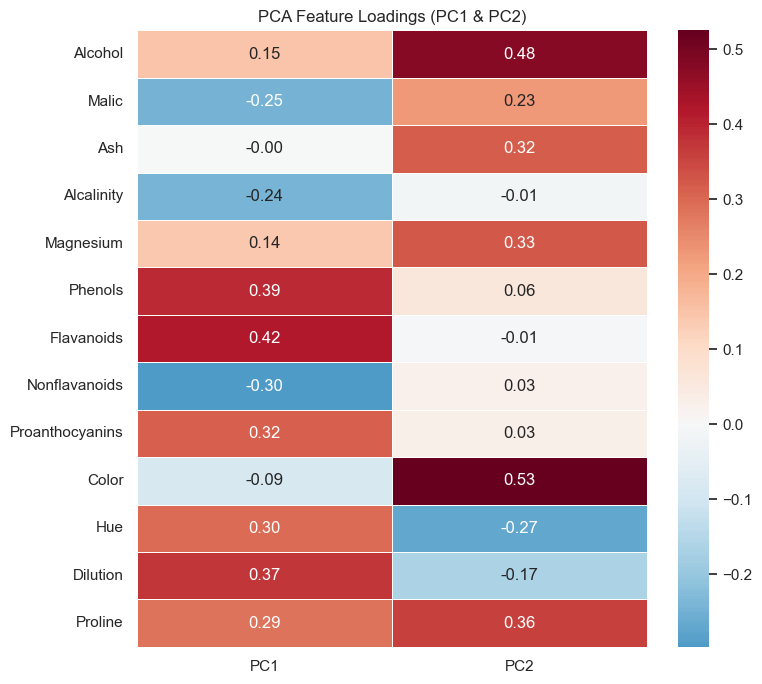

Top contributors to PC1 (sorted by absolute loading):
Flavanoids         0.421727
Phenols            0.393392
Dilution           0.374455
Proanthocyanins    0.316125
Nonflavanoids      0.296836


In [20]:
loadings_df = pd.DataFrame(
    pca2.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"])

plt.figure(figsize=(8, 7))
sns.heatmap(loadings_df, annot=True, cmap="RdBu_r", center=0,
            fmt=".2f", linewidths=0.5)
plt.title("PCA Feature Loadings (PC1 & PC2)")
plt.tight_layout()
plt.show()
print("Top contributors to PC1 (sorted by absolute loading):")
print(loadings_df["PC1"].abs().sort_values(ascending=False).head(5).to_string())

# Task 3 — Clustering on Original Scaled Data

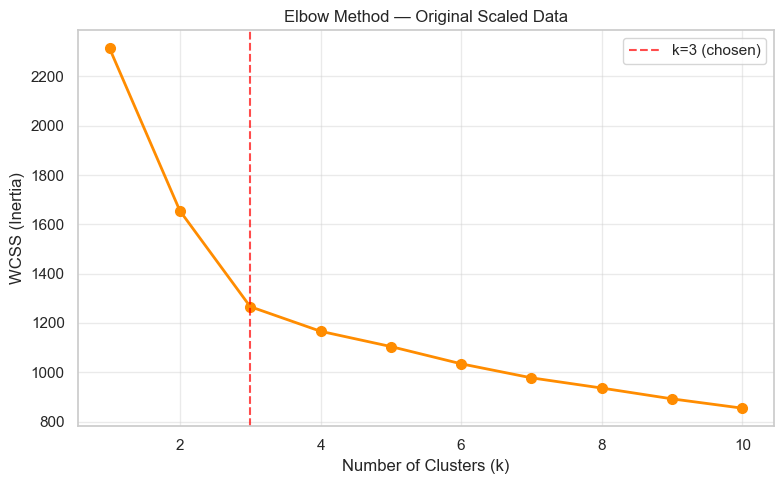

In [21]:
# ELBOW METHOD — Optimal k for K-Means
wcss = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    wcss.append(km.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker="o", color="darkorange", linewidth=2, markersize=7)
plt.axvline(x=3, color="red", linestyle="--", alpha=0.7, label="k=3 (chosen)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method — Original Scaled Data")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [22]:
# K-MEANS CLUSTERING — Original Scaled Data (k=3)
kmeans_orig    = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_orig  = kmeans_orig.fit_predict(x_scaled)

In [23]:
# --- Evaluation Metrics ---
sil_orig = silhouette_score(x_scaled, clusters_orig)
db_orig  = davies_bouldin_score(x_scaled, clusters_orig)

print("--- Clustering on Original Scaled Data (k=3) ---")
print(f"  Silhouette Score      : {sil_orig:.4f}   (higher is better, max=1)")
print(f"  Davies-Bouldin Index  : {db_orig:.4f}   (lower is better, min=0)")

--- Clustering on Original Scaled Data (k=3) ---
  Silhouette Score      : 0.2855   (higher is better, max=1)
  Davies-Bouldin Index  : 1.3816   (lower is better, min=0)


# VISUALISATION 10 — K-Means Clusters on Original Data (2D projection)

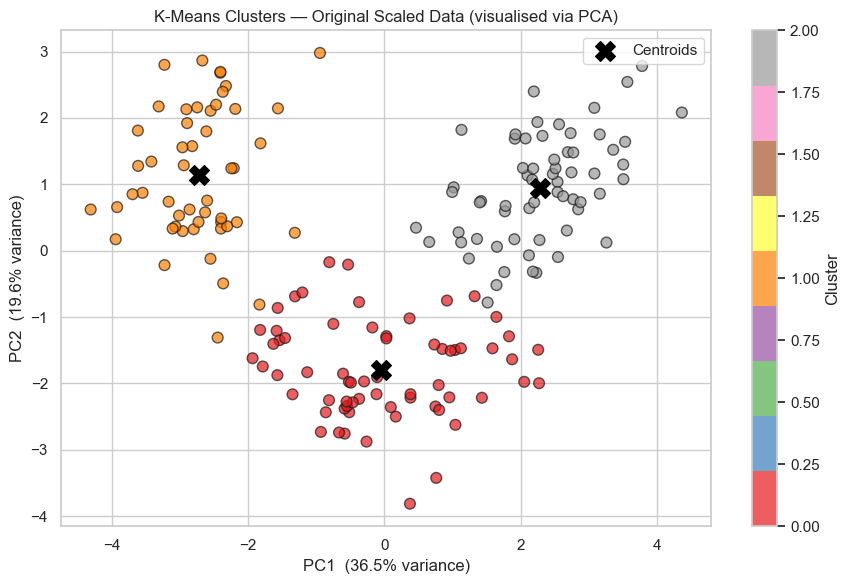

In [24]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(x_pca2[:, 0], x_pca2[:, 1],
                      c=clusters_orig, cmap="Set1", alpha=0.7,
                      edgecolors="k", s=60)
# Mark cluster centroids (projected to PCA space for visualisation)
centroids_pca = pca2.transform(kmeans_orig.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker="X", s=200, c="black", zorder=5, label="Centroids")
plt.xlabel(f"PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("K-Means Clusters — Original Scaled Data (visualised via PCA)")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.tight_layout()
plt.show()


# Task 4 — Clustering on PCA-Transformed Data

In [25]:
kmeans_pca   = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(x_pca2)

sil_pca = silhouette_score(x_pca2, clusters_pca)
db_pca  = davies_bouldin_score(x_pca2, clusters_pca)

print("--- Clustering on PCA-Transformed Data (2 components, k=3) ---")
print(f"  Silhouette Score      : {sil_pca:.4f}   (higher is better, max=1)")
print(f"  Davies-Bouldin Index  : {db_pca:.4f}   (lower is better, min=0)")


--- Clustering on PCA-Transformed Data (2 components, k=3) ---
  Silhouette Score      : 0.5613   (higher is better, max=1)
  Davies-Bouldin Index  : 0.5983   (lower is better, min=0)


# VISUALISATION 11 — K-Means Clusters on PCA-Transformed Data

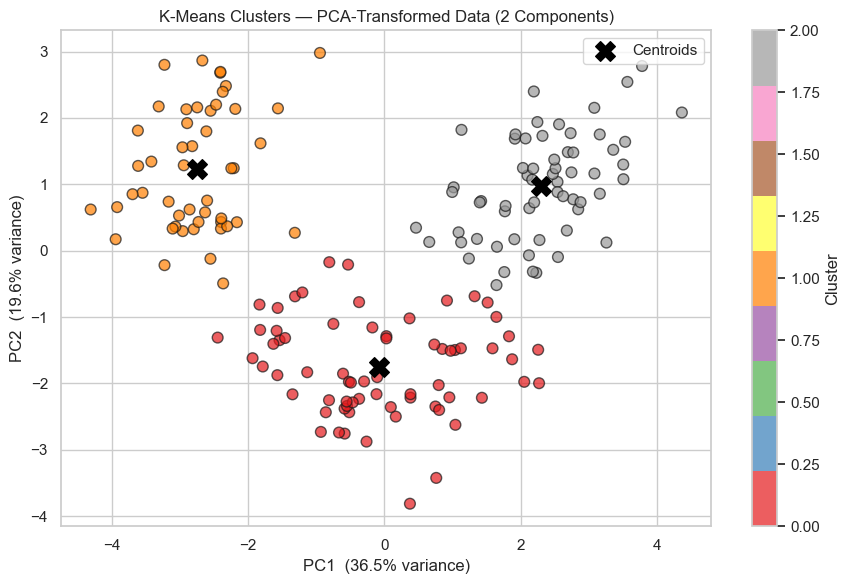

In [26]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(x_pca2[:, 0], x_pca2[:, 1],
                      c=clusters_pca, cmap="Set1", alpha=0.7,
                      edgecolors="k", s=60)
# Mark cluster centroids
centroids = kmeans_pca.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker="X", s=200, c="black", zorder=5, label="Centroids")
plt.xlabel(f"PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("K-Means Clusters — PCA-Transformed Data (2 Components)")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.tight_layout()
plt.show()

# Task 5 — Comparison and Analysis

In [27]:
# FULL COMPARISON — Original vs PCA Clustering
comparison_df = pd.DataFrame({
    "Metric"          : ["Silhouette Score (↑ better)", "Davies-Bouldin Index (↓ better)"],
    "Original Data"   : [round(sil_orig, 4), round(db_orig, 4)],
    "PCA Data (2D)"   : [round(sil_pca, 4),  round(db_pca, 4)]
})
print("-" * 55)
print("         CLUSTERING PERFORMANCE COMPARISON")
print("-" * 55)
print(comparison_df.to_string(index=False))
print("-" * 55)

# Automated verdict
if sil_pca > sil_orig:
    print("VERDICT : PCA-transformed data produced BETTER clustering.")
    print(f"          Silhouette improved by {sil_pca - sil_orig:.4f}")
else:
    print("VERDICT : Original data produced BETTER clustering.")
    print(f"          Silhouette was higher by {sil_orig - sil_pca:.4f}")


-------------------------------------------------------
         CLUSTERING PERFORMANCE COMPARISON
-------------------------------------------------------
                         Metric  Original Data  PCA Data (2D)
    Silhouette Score (↑ better)         0.2855         0.5613
Davies-Bouldin Index (↓ better)         1.3816         0.5983
-------------------------------------------------------
VERDICT : PCA-transformed data produced BETTER clustering.
          Silhouette improved by 0.2759


# VISUALISATION 12 — Side-by-Side Cluster Comparison

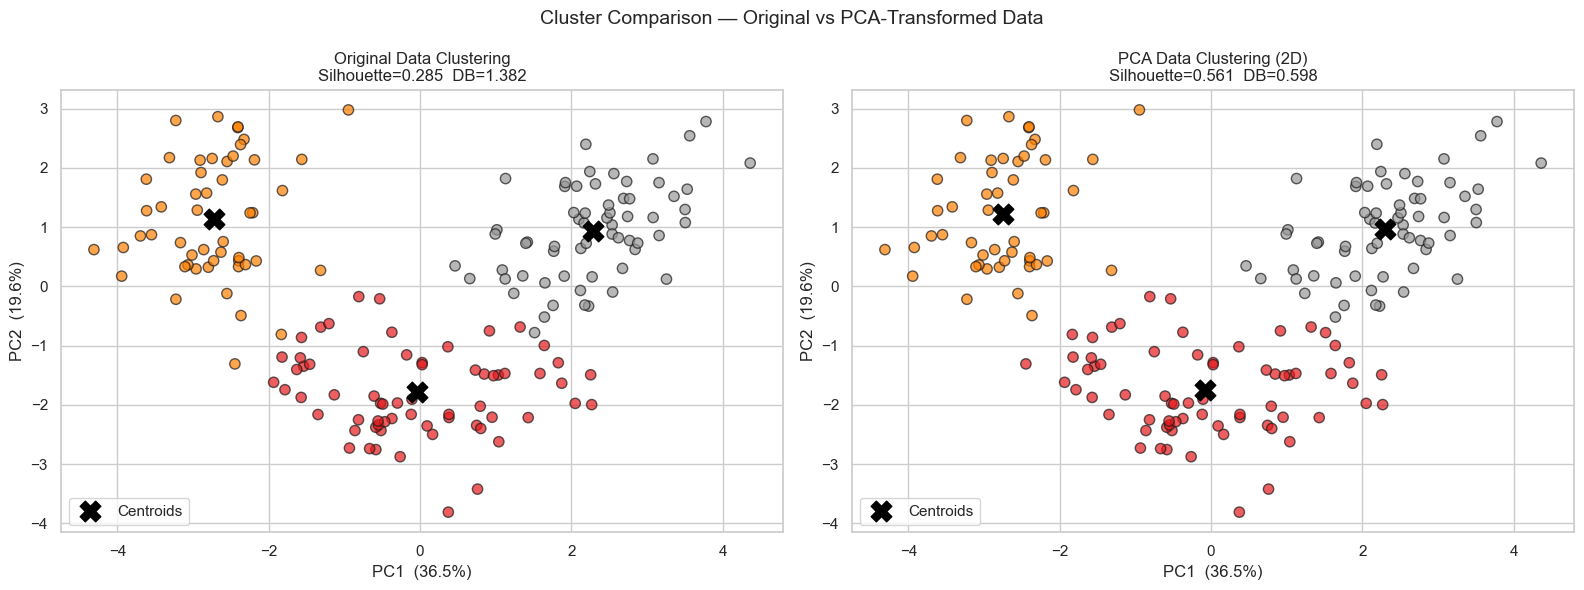

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Left — Original data clusters (visualised via PCA projection)
axes[0].scatter(x_pca2[:, 0], x_pca2[:, 1], c=clusters_orig,
                cmap="Set1", alpha=0.7, edgecolors="k", s=55)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker="X", s=220, c="black", zorder=5, label="Centroids")
axes[0].set_title(f"Original Data Clustering\nSilhouette={sil_orig:.3f}  DB={db_orig:.3f}")
axes[0].set_xlabel(f"PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend()

# Right — PCA data clusters
axes[1].scatter(x_pca2[:, 0], x_pca2[:, 1], c=clusters_pca,
                cmap="Set1", alpha=0.7, edgecolors="k", s=55)
axes[1].scatter(centroids[:, 0], centroids[:, 1],
                marker="X", s=220, c="black", zorder=5, label="Centroids")
axes[1].set_title(f"PCA Data Clustering (2D)\nSilhouette={sil_pca:.3f}  DB={db_pca:.3f}")
axes[1].set_xlabel(f"PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend()

plt.suptitle("Cluster Comparison — Original vs PCA-Transformed Data", fontsize=14)
plt.tight_layout()
plt.show()


# VISUALISATION 13 — Metric Comparison Bar Chart

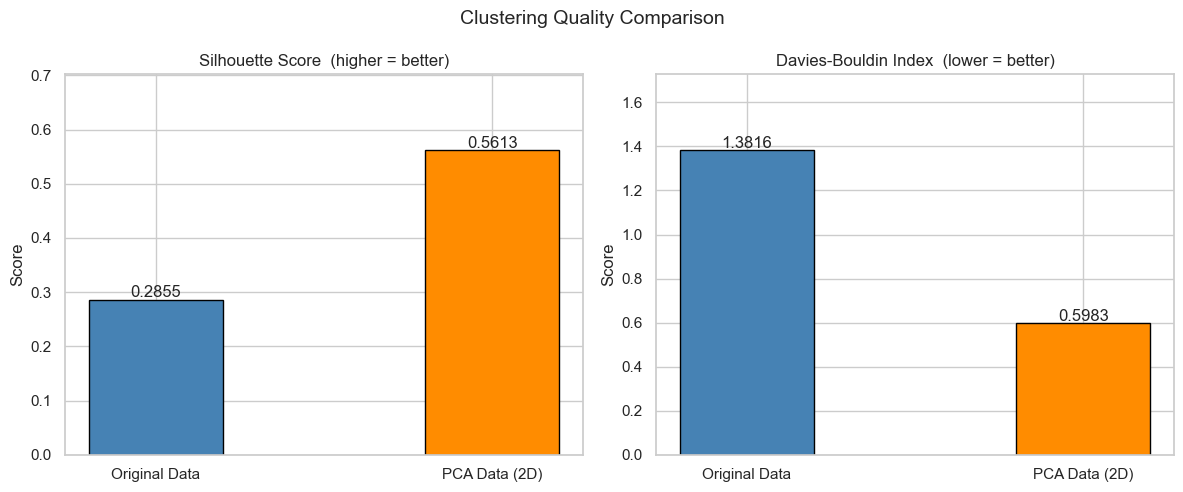

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Silhouette Score (higher is better)
axes[0].bar(["Original Data", "PCA Data (2D)"], [sil_orig, sil_pca],
            color=["steelblue", "darkorange"], edgecolor="black", width=0.4)
for i, v in enumerate([sil_orig, sil_pca]):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=12)
axes[0].set_title("Silhouette Score  (higher = better)")
axes[0].set_ylim(0, max(sil_orig, sil_pca) * 1.25)
axes[0].set_ylabel("Score")

# Davies-Bouldin Index (lower is better)
axes[1].bar(["Original Data", "PCA Data (2D)"], [db_orig, db_pca],
            color=["steelblue", "darkorange"], edgecolor="black", width=0.4)
for i, v in enumerate([db_orig, db_pca]):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=12)
axes[1].set_title("Davies-Bouldin Index  (lower = better)")
axes[1].set_ylim(0, max(db_orig, db_pca) * 1.25)
axes[1].set_ylabel("Score")

plt.suptitle("Clustering Quality Comparison", fontsize=14)
plt.tight_layout()
plt.show()


# Task 6 — Conclusion and Insights

Key Findings

PCA reduced the number of features while keeping most of the important information.

Clustering after PCA gave clearer and better-separated groups compared to using the original data.

The evaluation scores (silhouette and Davies–Bouldin) also showed improvement with PCA.

Practical Implications

PCA helps remove noise and simplifies the dataset, making clustering algorithms like K-means work better.

It also makes it easier to visualize data in 2D or 3D.

Recommendations

Use PCA when you have many features or when features are highly correlated.

Use clustering on original data when the dataset is small or when you want to interpret results using the original features